In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# load theoretical baseline
with open("./simulation_results/2026-04-10_13-41-34/test_results.json", "r") as f:
    mamba_cnn = json.load(f)

# load real CIFAR results
with open("./simulation_results/2026-05-02_20-14-27/test_results_model.json", "r") as f:
   transformer_results = json.load(f)

with open("./simulation_results/2026-04-10_19-38-43/test_results_bp.json", "r") as f:
    bp_results = json.load(f)

In [5]:
snr_vals = list(range(-10, 11))

In [6]:
import numpy as np

def shannon_limit_db(rate):
    snr = (2**rate - 1) / rate
    ebn0_db = 10 * np.log10(snr)
    return ebn0_db

In [7]:
mamba_ber = []

for snr in snr_vals:
    key = f"snr_{snr}_00"
    val = mamba_cnn["overall_metrics"].get(key, {}).get("average_BER", None)
    mamba_ber.append(val)

In [8]:
transformer_ber = []

for snr in snr_vals:
    key = f"snr_{snr}_00"
    val = transformer_results["overall_metrics"].get(key, {}).get("average_BER", None)
    transformer_ber.append(val)

In [9]:
bp_ber = []

for snr in snr_vals:
    key = f"snr_{snr}_00"
    val = bp_results["overall_metrics"].get(key, {}).get("average_BER", None)
    bp_ber.append(val)

In [10]:
shannon_db = shannon_limit_db(80/121)

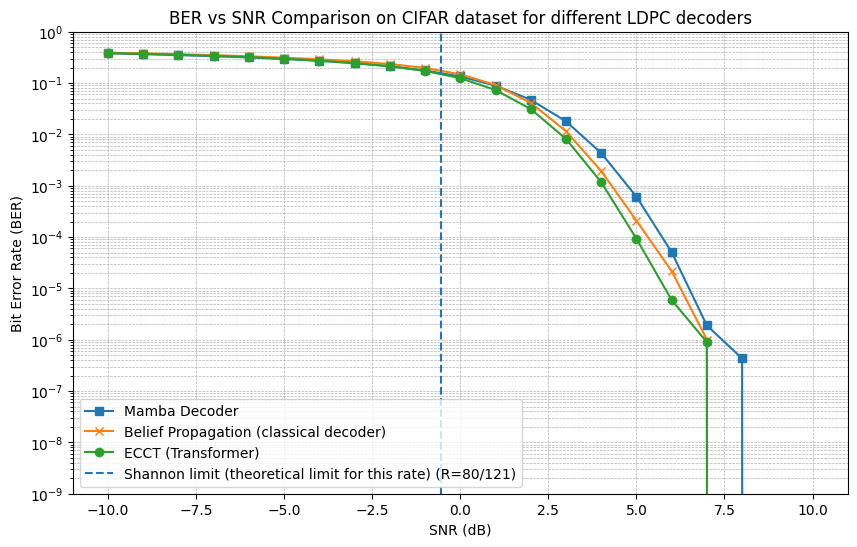

In [15]:
plt.figure(figsize=(10,6))


plt.plot(snr_vals, mamba_ber, marker='s', label="Mamba Decoder")
plt.plot(snr_vals, bp_ber, marker='x', label="Belief Propagation (classical decoder)")
plt.plot(snr_vals, transformer_ber, marker='o', label="ECCT (Transformer)")

plt.ylim(1e-9, 1)   
plt.axvline(
    shannon_db,
    linestyle="--",
    label=f"Shannon limit (theoretical limit for this rate) (R=80/121)"
)
plt.yscale("log")
plt.xlabel("SNR (dB)")
plt.ylabel("Bit Error Rate (BER)")
plt.title("BER vs SNR Comparison on CIFAR dataset for different LDPC decoders")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()

plt.show()

In [12]:
gap = []

for b, c in zip(baseline_ber, cifar_ber):
    if b is not None and c is not None and b != 0:
        gap.append(c / b)
    else:
        gap.append(None)

plt.figure(figsize=(10,6))
plt.plot(snr_vals, gap, marker='o')

plt.xlabel("SNR (dB)")
plt.ylabel("Performance Gap (CIFAR BER / Baseline BER)")
plt.title("Performance Gap vs SNR")
plt.grid(True)

plt.show()

NameError: name 'baseline_ber' is not defined

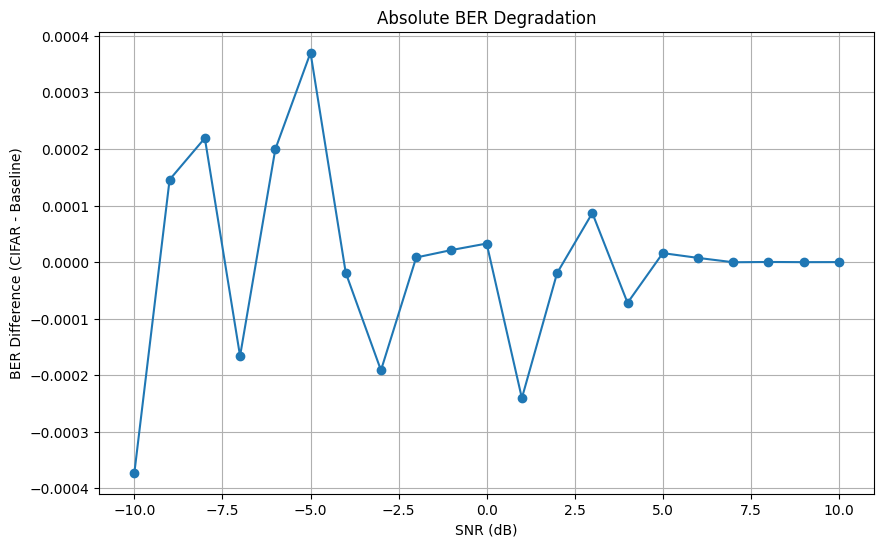

In [ ]:
diff = []

for b, c in zip(baseline_ber, cifar_ber):
    if b is not None and c is not None:
        diff.append(c - b)
    else:
        diff.append(None)

plt.figure(figsize=(10,6))
plt.plot(snr_vals, diff, marker='o')

plt.xlabel("SNR (dB)")
plt.ylabel("BER Difference (CIFAR - Baseline)")
plt.title("Absolute BER Degradation")
plt.grid(True)

plt.show()

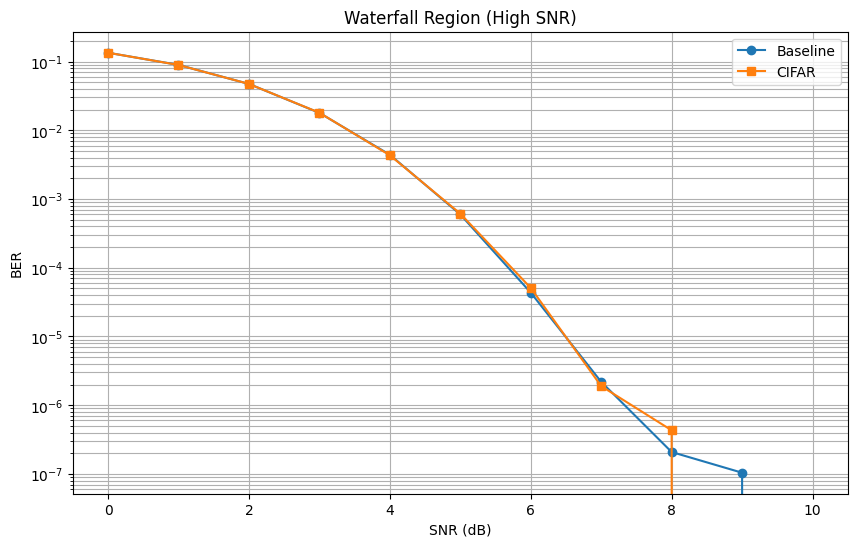

In [ ]:
plt.figure(figsize=(10,6))

high_snr = [i for i in range(len(snr_vals)) if snr_vals[i] >= 0]

plt.plot(np.array(snr_vals)[high_snr], np.array(baseline_ber)[high_snr], marker='o', label="Baseline")
plt.plot(np.array(snr_vals)[high_snr], np.array(cifar_ber)[high_snr], marker='s', label="CIFAR")

plt.yscale("log")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("Waterfall Region (High SNR)")
plt.grid(True, which="both")
plt.legend()

plt.show()

In [ ]:
def find_snr_for_ber(target_ber, snrs, bers):
    for i in range(len(bers)):
        if bers[i] is not None and bers[i] <= target_ber:
            return snrs[i]
    return None

target_bers = [1e-1, 1e-2, 1e-3, 1e-4]

print("SNR Gap Analysis:")
for tb in target_bers:
    snr_baseline = find_snr_for_ber(tb, snr_vals, baseline_ber)
    snr_cifar = find_snr_for_ber(tb, snr_vals, cifar_ber)

    if snr_baseline is not None and snr_cifar is not None:
        print(f"BER={tb}: ΔSNR = {snr_cifar - snr_baseline} dB")

SNR Gap Analysis:
BER=0.1: ΔSNR = 0 dB
BER=0.01: ΔSNR = 0 dB
BER=0.001: ΔSNR = 0 dB
BER=0.0001: ΔSNR = 0 dB
